In [6]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import PyComplexHeatmap as pch

In [3]:
# load data

female_gsva_scores_Wiki = pd.read_csv("/home/cvillazon/DEseq2_females/gsva_es_wiki.csv", header=0, index_col=0)
female_gsva_scores_GO = pd.read_csv("/home/cvillazon/DEseq2_females/gsva_es_go.csv", header=0, index_col=0)

male_gsva_scores_Wiki = pd.read_csv("/home/cvillazon/DEseq2_males/gsva_es_wiki.csv", header=0, index_col=0)
male_gsva_scores_GO = pd.read_csv("/home/cvillazon/DEseq2_males/gsva_es_go.csv", header=0, index_col=0)

In [ ]:

def gsva_score_plot(male_df, female_df, title):

    #shared pathways between females and males
    shared = male_df.index.intersection(female_df.index)

    male_shared = male_df.loc[shared]
    female_shared = female_df.loc[shared]

    male_shared.columns = pd.MultiIndex.from_product(
        [["Male"], male_shared.columns]
    )

    female_shared.columns = pd.MultiIndex.from_product(
        [["Female"], female_shared.columns]
    )

    combined = pd.concat([male_shared, female_shared], axis=1)

    combined = combined.fillna(0)

    col_meta = pd.DataFrame({
        "Sex": combined.columns.get_level_values(0),
        "Condition": combined.columns.get_level_values(1)
    }, index=combined.columns)

    sex_colors = {
        "Male": "#1BAE38",
        "Female": "#9168D3"
    }

    condition_colors = {
        "Tx.ZT0": "orange",
        "Tx.ZT12": "purple",
        "V.ZT0": "red",
        "V.ZT12": "blue"
    }

    col_colors = pd.DataFrame({
        "Sex": col_meta["Sex"].map(sex_colors),
        "Condition": col_meta["Condition"].map(condition_colors)
    })

    # Define the colors
    colors = ['#0041aa','#fefefe','#ab0000']
    # Create the colormap
    custom_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', colors)

    g = sns.clustermap(
        combined,
        cmap=custom_cmap,
        center=0,
        figsize=(12, 8),
        col_cluster=False,
        col_colors=col_colors
    )

    # Rotate & resize x tick labels
    plt.setp(
        g.ax_heatmap.get_xticklabels(),
        rotation=0,
        ha="center",
        fontsize=8
    )

    plt.title(f"GSVA Enrichment Scores - {title}", 
              fontsize=12, pad=20
              )

    # Optional: resize y labels
    plt.setp(
        g.ax_heatmap.get_yticklabels(),
        fontsize=9
    )

    # Optional: colorbar label
    g.cax.set_ylabel(
        "GSVA enrichment score",
        rotation=90,
        labelpad=-90,
        fontsize=8
    )

    g.ax_heatmap.set_xlabel("")
    g.ax_heatmap.set_xticklabels(
        [f"{sex}\n{cond}" for sex, cond in combined.columns],
        rotation=0,
        fontsize=8
    )
    g.ax_heatmap.set_ylabel("")
    plt.savefig(f'/home/cvillazon/results/enrichment_and_gsva/GSVA_cluster_{title}.pdf', bbox_inches='tight')
    plt.show()

    for label in sex_colors:
        g.ax_col_dendrogram.bar(0, 0, color=sex_colors[label],
                                label=label, linewidth=0)

    #for label in condition_colors:
    #    g.ax_col_dendrogram.bar(0, 0, color=condition_colors[label],
    #                            label=label, linewidth=0)

    g.ax_col_dendrogram.legend(
        title="Annotations",
        loc="center",
        ncol=2
    )

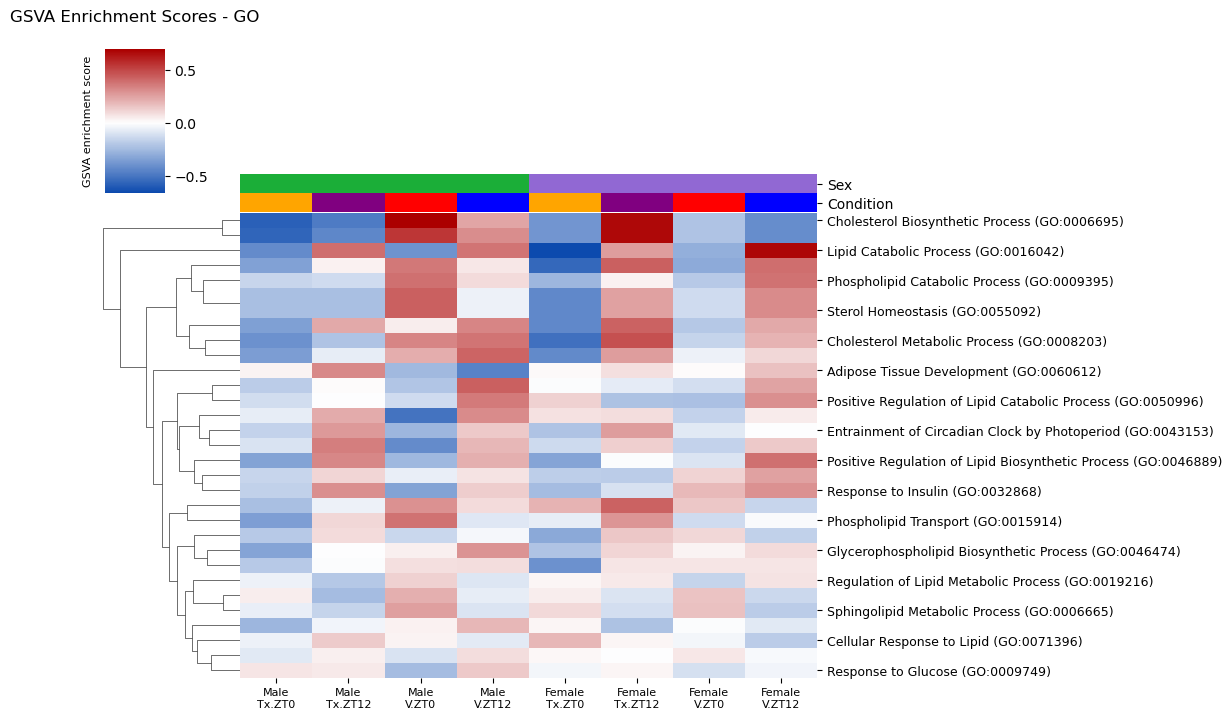

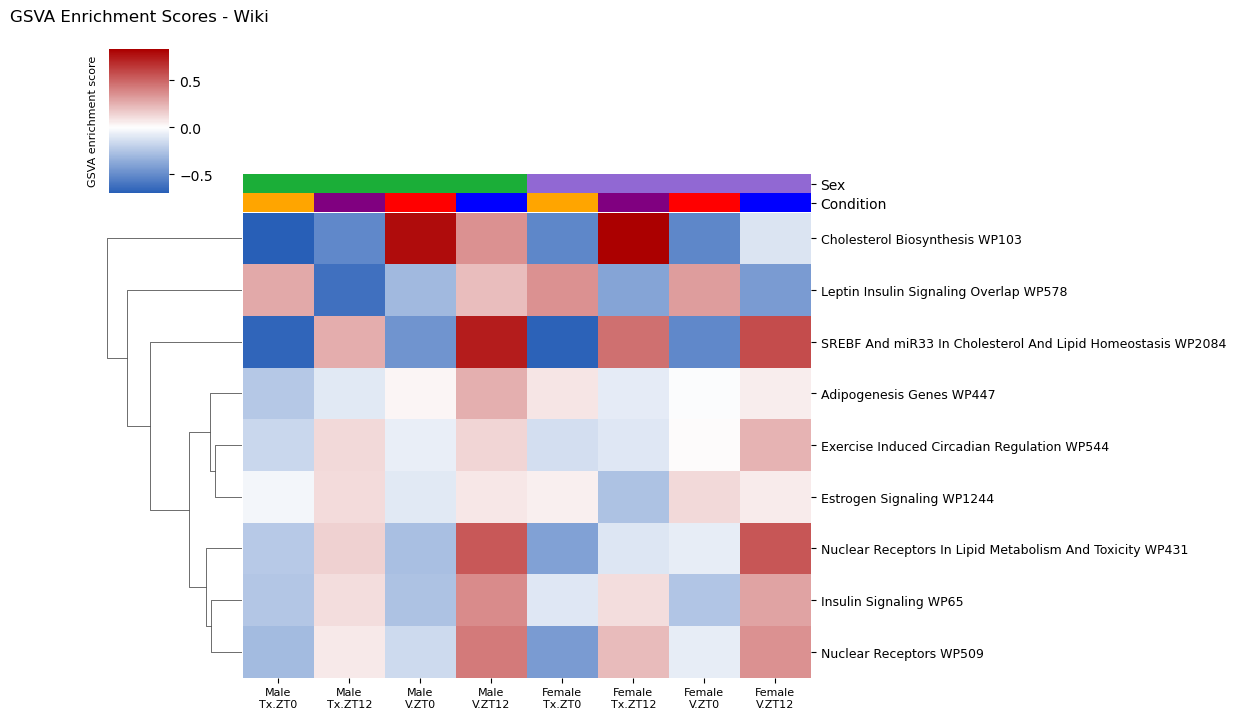

In [13]:
gsva_score_plot(male_gsva_scores_GO, female_gsva_scores_GO, "GO")
gsva_score_plot(male_gsva_scores_Wiki, female_gsva_scores_Wiki, "Wiki")